# Modeling

## 1. Train/Test Split

Es una técnica fundamental que consiste en dividir un conjunto de datos en dos subgrupos independientes para entrenar un modelo y evaluar objetivamente su rendimiento antes de ponerlo en producción.

In [5]:
from sklearn.model_selection import train_test_split
import pandas as pd

X= pd.read_csv("../data/processed/X_features.csv")
y= pd.read_csv("../data/processed/y_target.csv").squeeze()  # Convertir a Series

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size= 0.2,
    random_state=42,
    stratify=y
)

print("Features de entrenamiento:\n", X_train)
print("Features de test:\n", X_test)
print("Target de entrenamiento:\n", y_train)
print("Target de test:\n", y_test)

Features de entrenamiento:
            Age  Gender  EducationLevel       BMI  Smoking  AlcoholConsumption  \
780   1.233984       0               1  0.069329        0            1.492160   
1341 -1.436205       1               3  0.073937        1           -0.395390   
820   0.010147       0               0 -0.313781        0           -0.276172   
857   1.567757       0               0 -0.564590        0           -1.407125   
593   0.121405       1               2  1.540087        1           -0.178148   
...        ...     ...             ...       ...      ...                 ...   
1317 -1.658721       0               1  0.522402        0           -1.441286   
711  -1.658721       0               0 -1.012165        0            1.172555   
199   0.010147       1               1 -0.974625        1           -0.708713   
319   0.121405       1               0  0.823554        0           -0.826014   
802  -0.879916       1               2 -1.475348        0           -0.689721   


## 2. Selección y entrenamiento del modelo base

Un modelo base te da una referencia de rendimiento mínimo a superar.El modelo base se elige buscando la opción más simple e interpretable según el tipo de problema.

El proyecto tiene como objetivo predecir la detección temprana del Alzheimer, es decir, si un paciente puede o no tener Alzheimer. Por lo tanto, el modelo base se tiene que elegir para la clasificación binaria con datos tabulares.

Para este caso se probaran todos los modelos para la clasificación binaria.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

models = {
    "Logistic Regression": LogisticRegression(max_iter=100, random_state=16, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=16, class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier(random_state=16),
    "SVM": CalibratedClassifierCV(SVC(class_weight='balanced', random_state=16), ensemble=False),
    "KNN": KNeighborsClassifier(),
}

trained_models = {}
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    y_pred = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": model.score(X_test, y_test),
        "Precision": classification_report(y_test, y_pred, output_dict=True)['1']['precision'],
        "Recall": classification_report(y_test, y_pred, output_dict=True)['1']['recall'],
        "F1-Score": classification_report(y_test, y_pred, output_dict=True)['1']['f1-score']
    })

results_df = pd.DataFrame(results)
print(results_df)


                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.811628   0.685864  0.861842  0.763848
1        Random Forest  0.946512   0.938776  0.907895  0.923077
2    Gradient Boosting  0.946512   0.927152  0.921053  0.924092
3                  SVM  0.851163   0.801370  0.769737  0.785235
4                  KNN  0.741860   0.684685  0.500000  0.577947


## 3. Interpretación

Revisar cuáles son las variables más relevantes.

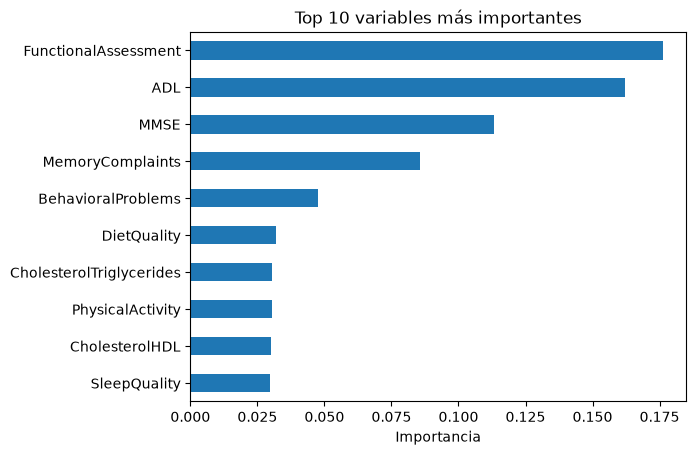

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Recuperamos directamente el modelo Random Forest
rf_model = trained_models["Random Forest"]

# Usa X_train.columns o X.columns según el DataFrame con el que entrenaste
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(10).plot(kind='barh')

plt.title("Top 10 variables más importantes")
plt.xlabel("Importancia")
plt.gca().invert_yaxis()
plt.show()

## 4. Reentrenar modelos con las variables más significativas


In [8]:
top_features = ["FunctionalAssessment", "ADL", "MMSE", "MemoryComplaints",
                 "BehavioralProblems", "DietQuality", "CholesterolTriglycerides",
                 "PhysicalActivity", "CholesterolHDL", "SleepQuality"]

X_top = X[top_features]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_top, y, test_size=0.2, random_state=42, stratify=y
)

results = []
for name, model in models.items():
    model.fit(X_train2, y_train2)
    y_pred = model.predict(X_test2)
    
    results.append({
        "Model": name,
        "Accuracy": model.score(X_test2, y_test2),
        "Precision": classification_report(y_test2, y_pred, output_dict=True)['1']['precision'],
        "Recall": classification_report(y_test2, y_pred, output_dict=True)['1']['recall'],
        "F1-Score": classification_report(y_test2, y_pred, output_dict=True)['1']['f1-score']
    })

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.813953   0.697802  0.835526  0.760479
1        Random Forest  0.955814   0.946309  0.927632  0.936877
2    Gradient Boosting  0.948837   0.933333  0.921053  0.927152
3                  SVM  0.886047   0.860140  0.809211  0.833898
4                  KNN  0.797674   0.777778  0.598684  0.676580


## 5. Simular predicción de un paciente

In [ ]:
# Prueba con un paciente del test set
paciente_nuevo = X_test2.iloc[[0]]

pred = trained_models["Random Forest"].predict(paciente_nuevo)
prob = trained_models["Random Forest"].predict_proba(paciente_nuevo)

print("Diagnóstico real:", y_test2.iloc[0])
print("Diagnóstico predicho:", pred[0])
print("Probabilidad [sano, Alzheimer]:", prob[0])

Diagnóstico real: 1
Diagnóstico predicho: 1
Probabilidad [sano, Alzheimer]: [0.04 0.96]


## 6. Guardar modelo y features

In [14]:
import joblib

joblib.dump(trained_models["Random Forest"], '../models/alzheimer_rf_model.pkl')
joblib.dump(top_features, '../models/top_features.pkl')

['../models/top_features.pkl']